In [1]:
from fastai.vision.all import *

## Approch 1

- Use CNN to classify fall or not fall
- The classical way

In [2]:
from pathlib import Path
import os 
from make import load_primary_data

spec, labels = load_primary_data()

from validation_util import split

valid_spec, valid_labels = split(spec, 120, labels=labels)


Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Gene

In [3]:
len(spec)

1080

In [4]:
len(labels)

1080

In [5]:
len(valid_labels)

120

In [6]:
len(labels)

1080

In [7]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (33, 128)
Final shape: (33, 36)


In [8]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [10]:
def get_x(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return labels[i]

In [11]:
from plot_util import PlotUtil
from tourch_util import TorchUtil

tu = TorchUtil(all_spectrograms=spec, 
               all_labels=labels, 
               TARGET_CH=TARGET_CH, 
               EPS=EPS, 
               FLOOR_DB=FLOOR_DB, 
               TARGET_HW=TARGET_HW)

In [12]:
type(spec[4])

numpy.ndarray

In [13]:
spec[4].shape

(33, 153)

In [14]:
from plot_util import PlotUtil

plotUtil = PlotUtil(spectrograms=spec)

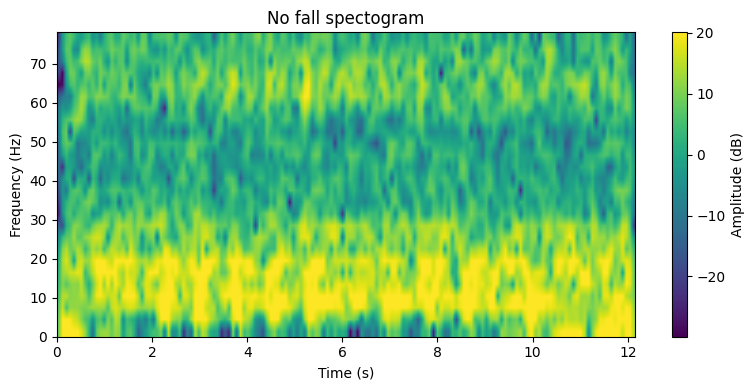

In [15]:
# Sxx_db: (F, T)
plotUtil.show_spec(4, "No fall spectogram")

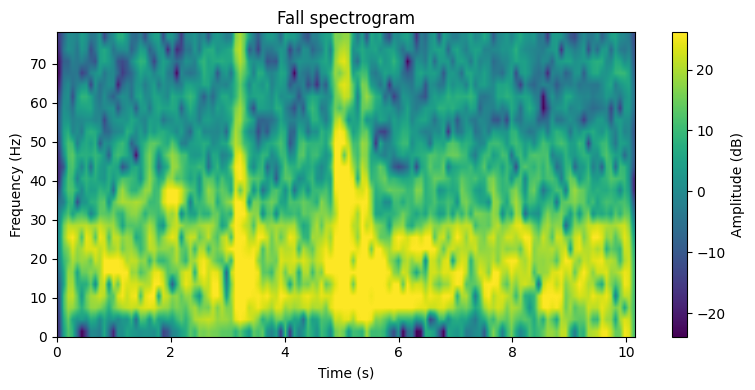

In [16]:
plotUtil.show_spec(0, "Fall spectrogram")

In [17]:
tensor_img = get_x(0)

<Axes: >

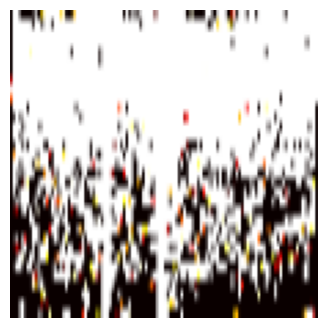

In [18]:
fig, ax = plt.subplots(figsize=(4,4))

tensor_img.show(ax=ax)


In [19]:
get_y(4)

'Not Fall'

In [20]:
tensor_img = tu.get_x(4)

/media/Delta/code/Master/Master-project/vibration_model/tourch_util.py:20: RuntimeWarning: invalid value encountered in log10
  arr_db = 10 * np.log10(self.all_spectrograms[i])


In [21]:
import fastai


block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [22]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

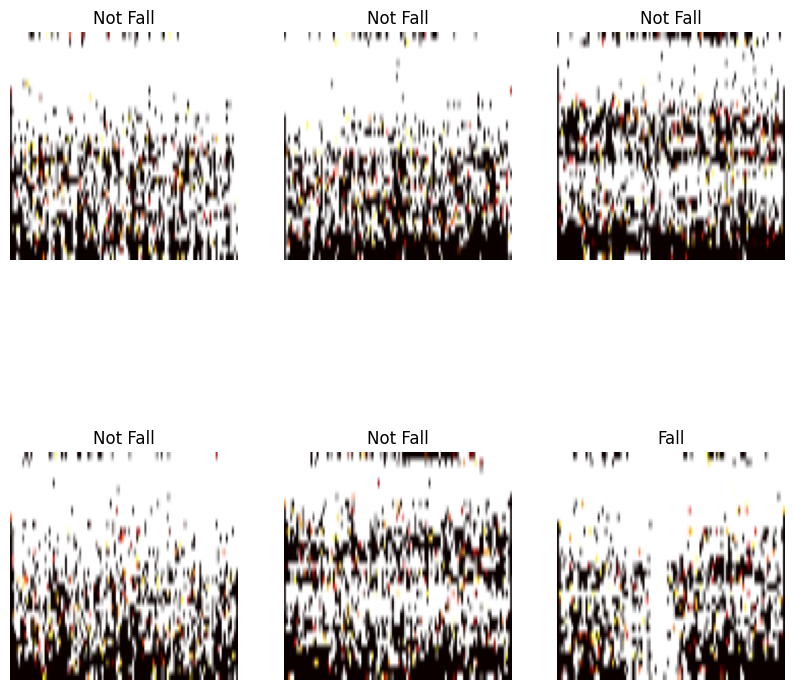

In [23]:
dls.show_batch(max_n=6, figsize=(10,10))

## Only run if you dont have a learner yet! 

epoch,train_loss,valid_loss,accuracy,time
0,0.675865,0.432371,0.754630,00:01
1,0.449737,0.317240,0.842593,00:01
2,0.290628,0.237973,0.958333,00:01
3,0.262951,0.238164,0.847222,00:01
4,0.197688,0.178587,0.972222,00:01
5,0.180041,0.111355,0.907407,00:01
6,0.231867,0.208880,0.773148,00:01
7,0.137807,0.032448,0.976852,00:01
8,0.149327,0.111906,0.986111,00:01
9,0.114160,0.053990,0.990741,00:01


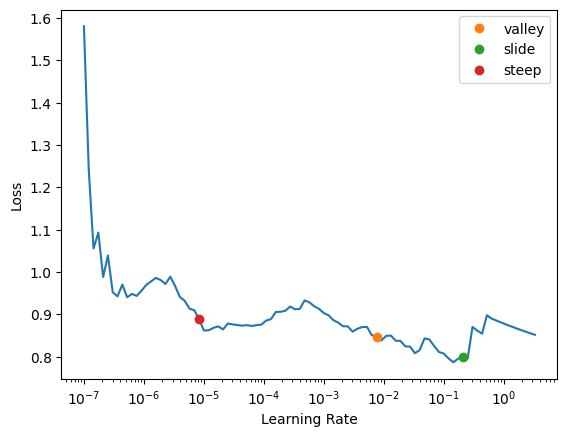

In [24]:
learner = vision_learner(dls, resnet18, metrics=accuracy, loss_func=CrossEntropyLossFlat())
learner.model[-1] = nn.Sequential(learner.model[-1], nn.ReLU())
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))
learner.fit_one_cycle(15, lr.valley)

In [25]:
learner.summary()

Sequential (Input shape: 12 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 64 x 56 x 56   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

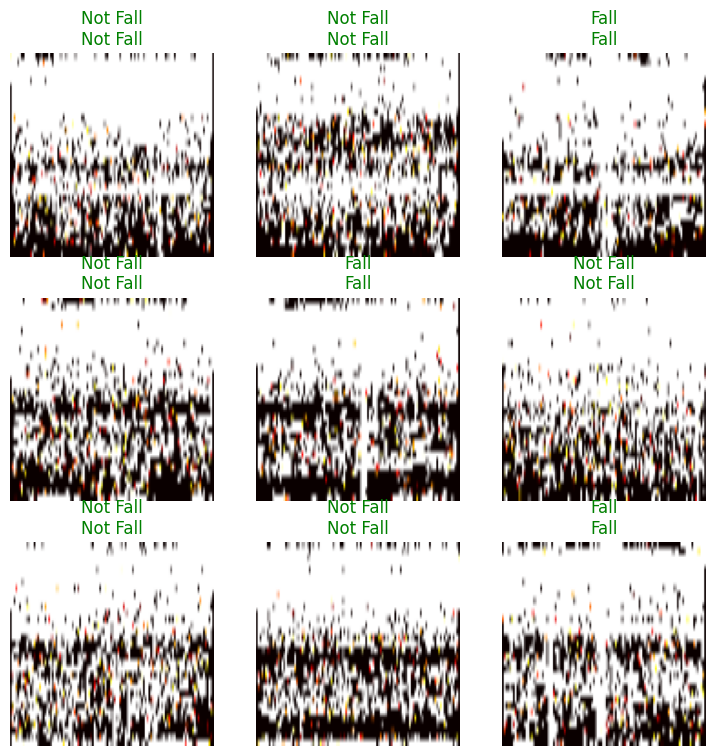

In [26]:
learner.show_results()

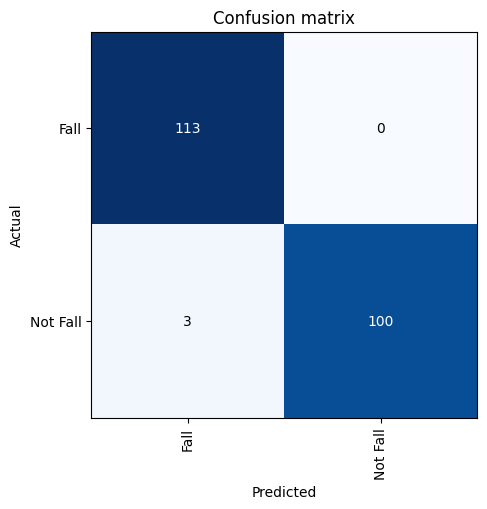

In [27]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [27]:
if not learner:
    learner = load_learner('./models/autoencoder.pkl')

In [28]:
def get_x_test(i):
    arr = valid_spec[i]
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [29]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [31]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [32]:
learner.predict(get_x_test(4))

('Not Fall', tensor(1), tensor([1.5324e-07, 1.0000e+00]))

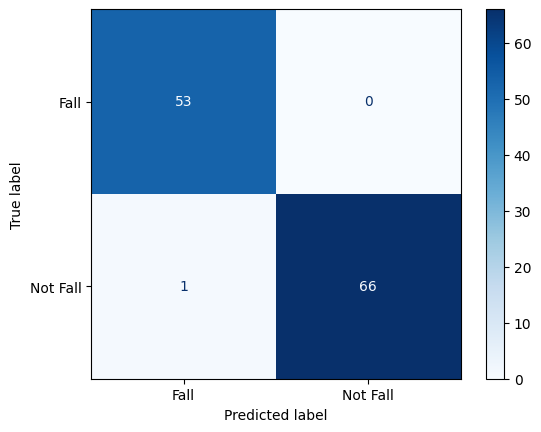

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [34]:
accuracy_score(y_test, y_pred)

0.9916666666666667

In [35]:
precision_score(y_test, y_pred, average='macro')

0.9907407407407407

In [36]:
recall_score(y_test, y_pred, average="macro")

0.9925373134328358

In [37]:
f1_score(y_test, y_pred, average="macro")

0.9915677043074977

In [39]:
dir = Path('./models')

learner.path = dir

learner.export('sd-model.pkl')